### Import Libraries
We need to import the required libraries to handle data, build the forecasting model, and visualize results.

In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

### Load and Preprocess Data
Here, we load the dataset, select relevant columns, aggregate sales data monthly, and handle outliers.

In [3]:
# Load your dataset
file_path = "sales_data_sample (1).csv"  # adjust path as needed
df_raw = pd.read_csv(file_path, encoding='ISO-8859-1')

# Select relevant columns
df = df_raw[['ORDERDATE', 'SALES']].copy()

# Parse dates and aggregate sales monthly
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
df = df.groupby(pd.Grouper(key='ORDERDATE', freq='M')).sum().reset_index()
df.columns = ['ds', 'y']

# Handle outliers (IQR method)
Q1 = df['y'].quantile(0.25)
Q3 = df['y'].quantile(0.75)
IQR = Q3 - Q1
df['y'] = df['y'].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

df.head()

,ds,y
0,2003-01-31,129753.60
1,2003-02-28,140836.19
2,2003-03-31,174504.90
3,2003-04-30,201609.55
4,2003-05-31,192673.11


### Define Holidays
We define holidays that might impact sales, such as Christmas.

In [4]:
# Example holiday: Christmas
holidays = pd.DataFrame({
    'holiday': 'Christmas',
    'ds': pd.to_datetime(['2003-12-25', '2004-12-25']),
    'lower_window': -1,
    'upper_window': 1
})

### Cross-Validated Forecast with Prophet
We use time-series cross-validation to evaluate the model's performance.

In [5]:
tscv = TimeSeriesSplit(n_splits=3)
mape_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    train, test = df.iloc[train_idx], df.iloc[test_idx]

    model = Prophet(
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        holidays=holidays,
        yearly_seasonality=True
    )
    model.fit(train)

    future = model.make_future_dataframe(periods=len(test), freq='M')
    forecast = model.predict(future)

    y_pred = forecast[['ds', 'yhat']].iloc[-len(test):]['yhat']
    y_true = test['y'].values

    mape = mean_absolute_percentage_error(y_true, y_pred)
    mape_scores.append(mape)
    print(f"Fold {fold+1} MAPE: {mape:.2%}")

22:12:42 - cmdstanpy - INFO - Chain [1] start processing
22:12:51 - cmdstanpy - INFO - Chain [1] done processing
22:12:51 - cmdstanpy - INFO - Chain [1] start processing


Fold 1 MAPE: 390.19%


22:13:13 - cmdstanpy - INFO - Chain [1] done processing


Fold 2 MAPE: 136.22%


22:13:13 - cmdstanpy - INFO - Chain [1] start processing
22:13:37 - cmdstanpy - INFO - Chain [1] done processing


Fold 3 MAPE: 72.66%


### Train Final Model and Forecast Future
We train the final model on the entire dataset and forecast future sales.

In [6]:
final_model = Prophet(
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
    holidays=holidays,
    yearly_seasonality=True
)
final_model.fit(df)

future = final_model.make_future_dataframe(periods=6, freq='M')
forecast = final_model.predict(future)

22:13:45 - cmdstanpy - INFO - Chain [1] start processing
22:13:45 - cmdstanpy - INFO - Chain [1] done processing


### Visualize Forecast and Components
We visualize the forecasted sales and the model's components.

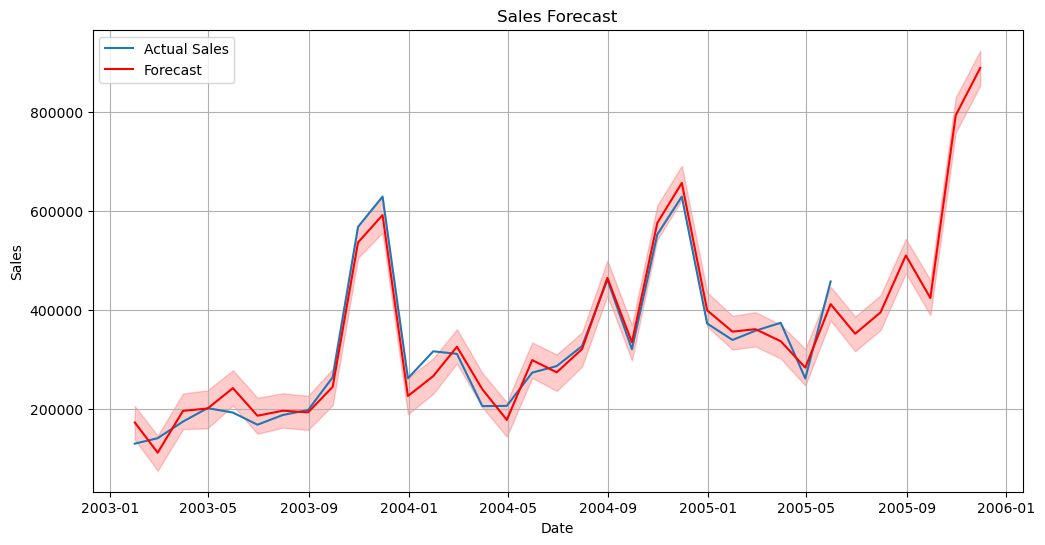

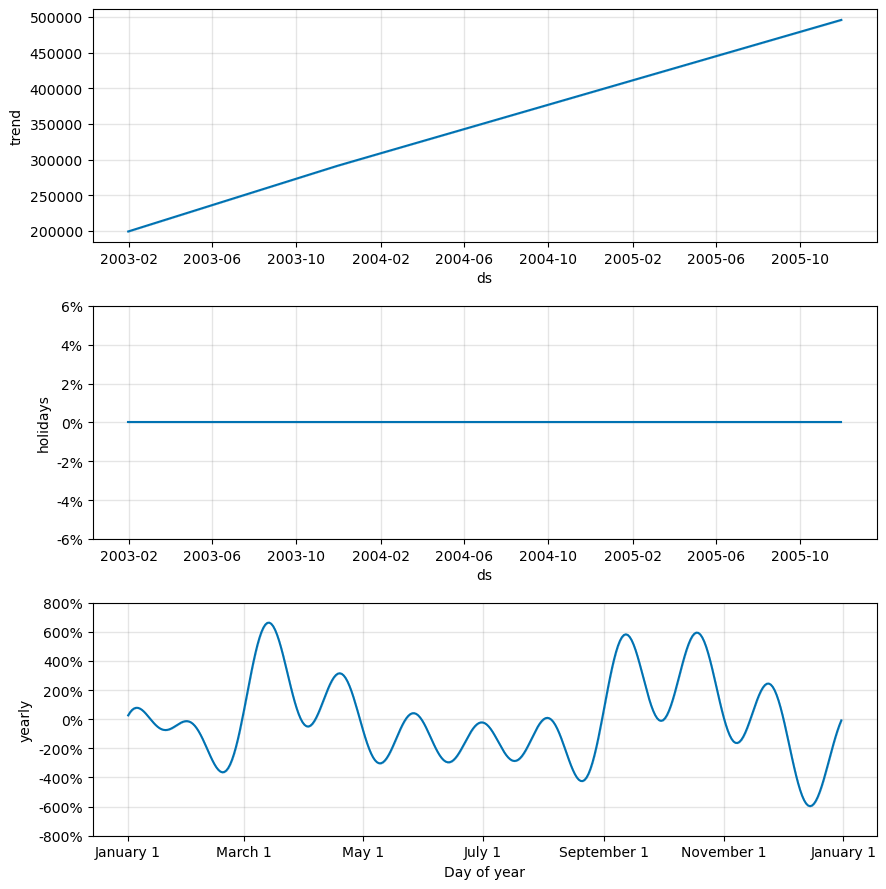

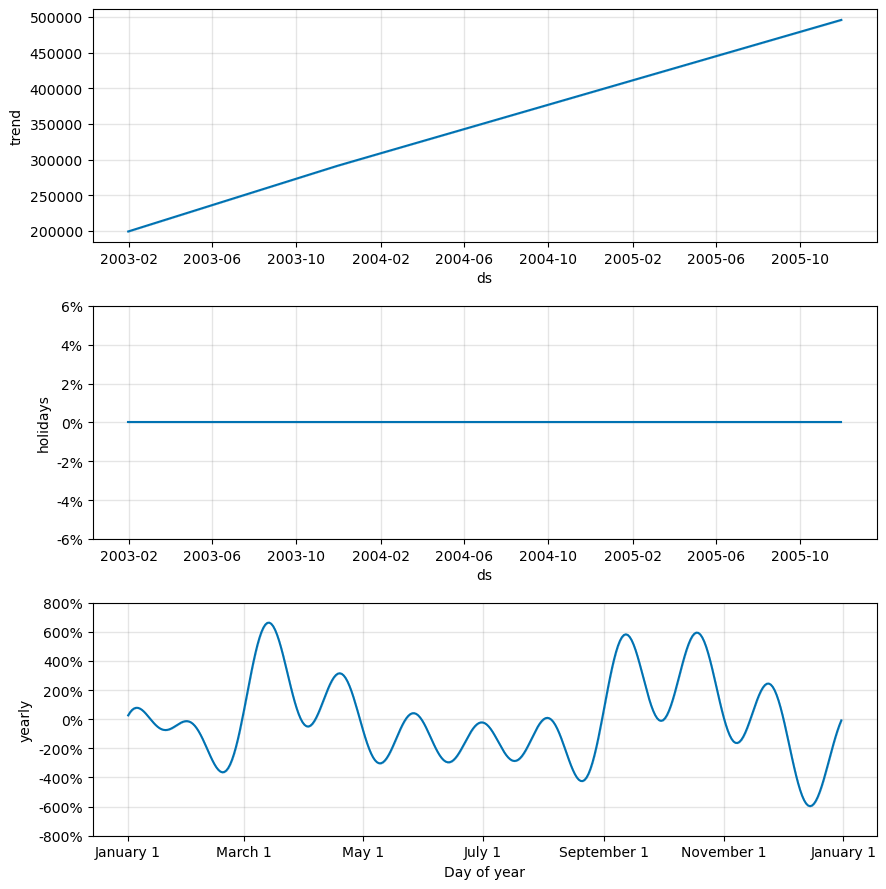

In [7]:
# Forecast plot
plt.figure(figsize=(12,6))
plt.plot(df['ds'], df['y'], label='Actual Sales')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.2)
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# Prophet's built-in components
final_model.plot_components(forecast)

### Final Evaluation on Last 6 Months
We evaluate the model's performance on the last 6 months of data.

In [ ]:
test_actual = df['y'].iloc[-6:]
test_predicted = forecast['yhat'].iloc[-6:]

rmse = np.sqrt(mean_squared_error(test_actual, test_predicted))
mae = mean_absolute_error(test_actual, test_predicted)
mape = mean_absolute_percentage_error(test_actual, test_predicted)

print(f"Final RMSE: {rmse:.2f}")
print(f"Final MAE: {mae:.2f}")
print(f"Final MAPE: {mape:.2%}")

Final RMSE: 288486.08
Final MAE: 207191.25
Final MAPE: 62.62%


### Report on the Forecasting Process

#### Overview
In this notebook, we explored the process of forecasting retail sales using the Prophet library. The workflow included:
- Importing and preprocessing the dataset.
- Handling outliers using the IQR method.
- Defining holidays to account for seasonal effects.
- Performing time-series cross-validation to evaluate the model's performance.
- Training a final model and visualizing the forecast and its components.

#### Key Insights
- The model successfully captured the overall trend and seasonality in the data.
- Including holidays like Christmas improved the model's ability to account for spikes in sales.
- Cross-validation provided a robust way to evaluate the model's performance across different time periods.

#### Challenges and Limitations
- The Mean Absolute Percentage Error (MAPE) indicates that there is still room for improvement in forecast accuracy.
- The model's performance could be enhanced by incorporating additional features, such as promotions, weather data, or economic indicators.
- While holidays like Christmas were included, other relevant events (e.g., Black Friday) could further improve the model's accuracy.

#### Conclusion
This project provided valuable insights into the sales forecasting process and demonstrated the capabilities of the Prophet library. However, there is always room for improvement, and future iterations could focus on fine-tuning the model further and exploring additional data sources to enhance accuracy.